# Homework 1

### CS328 — Numerical Methods for Visual Computing and Machine Learning
- - -

<div style="text-align: center"> 
<br> <b>This is an autograded assignment.</b> 
<br><br> 
<b>Due: 01.10.2025 at 21:00 (UTC+2) </b> <br><br> </div>

This notebook contains literate code, i.e. brief fragments of Python surrounded by descriptive text. Please complete/extend this notebook for your homework submission:

* Only write your solution code in the areas that start with "`# YOUR CODE HERE`". Please do not change the variable names that are set as ellipsis `(...)` and indicate your solution using these variables. You can add more cells to test your answer.
  
* We are using cell tags to prevent you from editing or deleting cells that are required for our grading tool. If you are using Jupyter Lab / Notebook, you do not need to worry about this, as long as you do not try to delete/change content of cells that Jupyter Lab/Notebook does not let you edit by default. If you are using some other IDE (VS-code, PyCharm, etc), **you have full responsibility to make sure that the cell tags are not modified, and that you do not change the code of cells with tag `"editable": false`** . Especially, you should not delete any of the existing cells from the Notebook. 
  
* Before handing in, **please make sure that your notebook runs from top to bottom after selecting "Kernel->Restart & Run All"** without causing any errors. If an exception raise during the correction, zero points will be assigned to the question.

Make sure to use the reference Python distribution so that project files can be opened by the TAs. In this course, we use <a href="https://www.anaconda.com/products/individual">Anaconda</a>, specifically the version based on Python 3.13.

<div class="alert alert-warning">
Homework assignments in CS328 count towards your final grade and must therefore be done individually.
</div>

> © Realistic Graphics Lab - EPFL (2025). This notebook is property of the Realistic Graphics Lab at EPFL and may not be redistributed. Posting of notebooks and/or solutions on the web (e.g. on GitHub) is not permitted.

### Prelude

The following fragment imports NumPy and Matplotlib and configures the latter to produce nice graphics even on recent high-resolution screens. The import statements at the end establish a shorthand notation for the most common integer and floating point formats.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import random as rnd
import numpy as np
from matplotlib import pyplot as plt

from numpy import uint16  as u16
from numpy import uint32  as u32
from numpy import uint64  as u64
from numpy import float16 as f16
from numpy import float32 as f32
from numpy import float64 as f64

Two more definitions: the helper functions ``f2i`` and ``i2f``  below reinterpret floating point values as an integers and vice versa. We'll use these in Problem 3 to access the bit-level representation of an IEEE 754 floating point value.

In [2]:
def f2i(value):
    ''' Reinterpret floating point value as integer '''
    return value.view('u%i' % value.itemsize)

def i2f(value):
    ''' Reinterpret integer as floating point value '''
    return value.view('f%i' % value.itemsize)

## Problem 1: Images, slicing, and color balancing (15 pts)

The following two lines of code download a portrait photograph from the Wikipedia article on [color balance](https://en.wikipedia.org/wiki/Color_balance) and store it in a single precision NumPy array named ``image``, whose pixels are in the range ``[0.0, 1.0]``.

In [3]:
import PIL, requests
from PIL import Image
image = np.array(Image.open(requests.get('https://goo.gl/VcYNGN', stream=True, headers = {'User-agent': 'Mozilla/5.0'}).raw), dtype = np.float32) / 255

Try plotting this image using ``plt.imshow``.

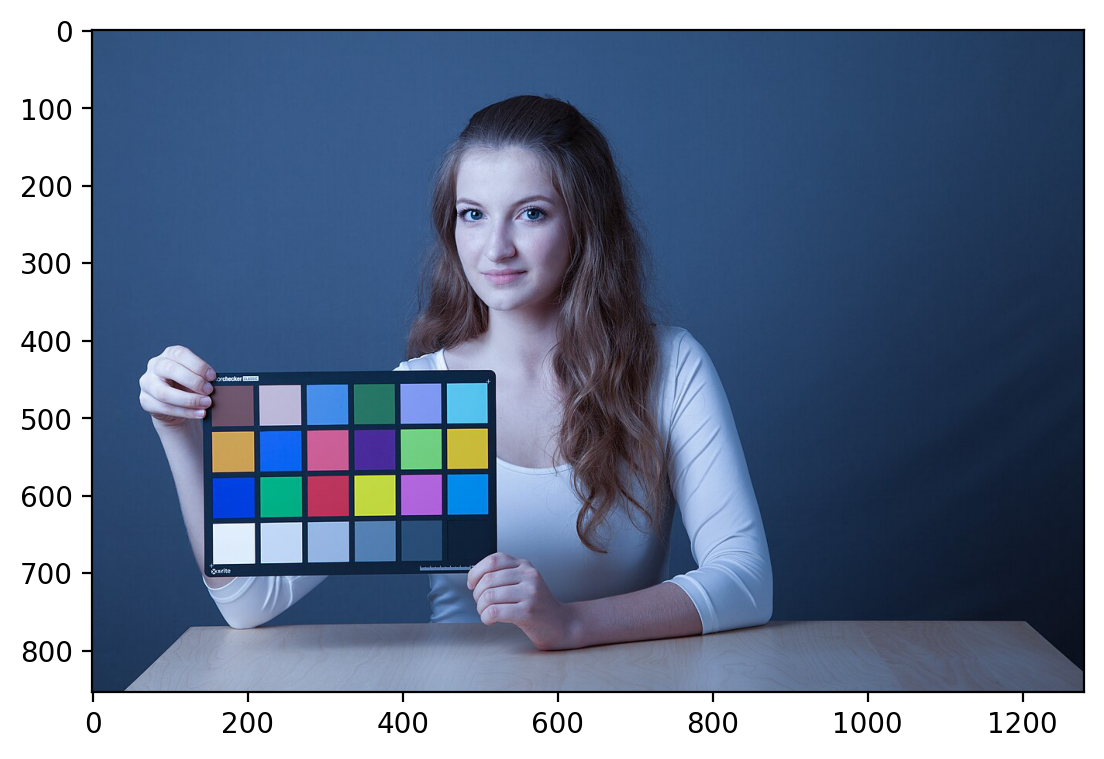

In [4]:
plt.imshow(image)
plt.show()

You will notice that the colors are distorted by a strong blue tint. Such intense color casts can lead to unnatural appearance and are usually not desired in portrait photography. In such cases, *color balancing* can be used to post-process the colors of an existing image to e.g. ensure that white objects indeed appear white in the image. One of the simplest kinds of color balancing is known as *white balancing*. Here, we select a region of the image that is known to contain a neutral color, and we then determine the reciprocal of the associated red, green, and blue color values. Afterwards, the color channels of the entire image are scaled by these reciprocals, ensuring that the selected region becomes neutral (i.e. it has similar amounts of red, green, and blue).

Note that the woman holds a [color checker](https://en.wikipedia.org/wiki/ColorChecker) in her hands. A color checker consists of an arrangement of colored patches with known color values, and the last row usually contains neutral colors. We will  use the second neutral patch on the bottom left to white-balance this image.

**TODO**: Use NumPy *slicing* operations to crop out the second neutral patch in the last row (counting from the left side) and plot it using ``plt.imshow``. The cropped region should be as large as possible without including the black frame or other patches.

(853, 1280, 3)


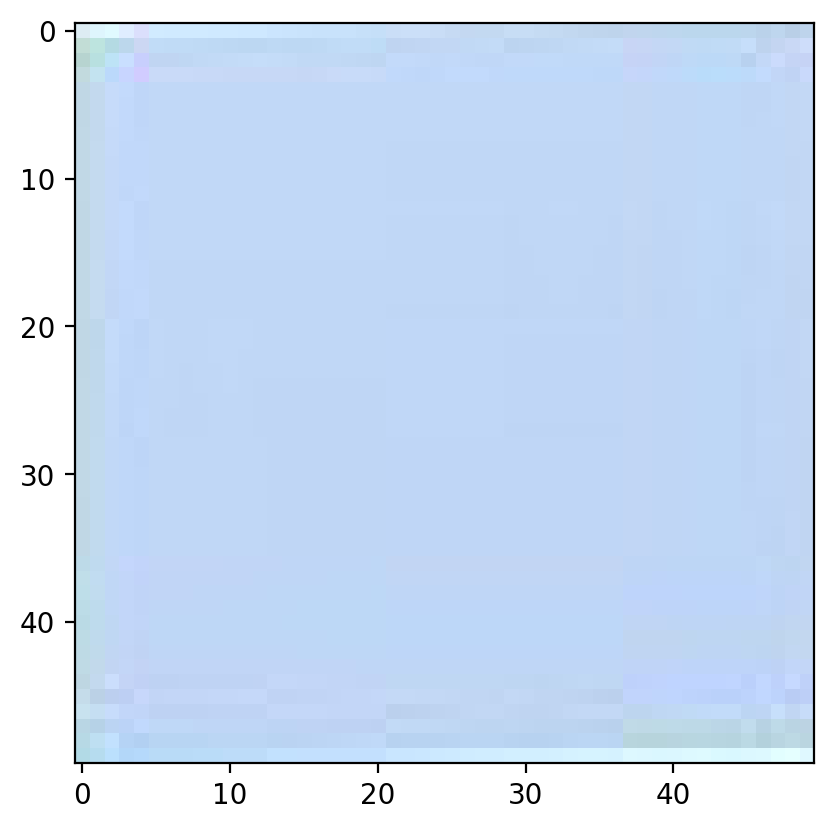

In [5]:
def crop_image(input_image):
    '''
    Returns the cropped region
    '''
    print(input_image.shape)
    cropped = input_image[636:686, 219:269, :]
    return cropped

cropped = crop_image(image)
plt.imshow(cropped)
plt.show()

In [6]:
assert ((cropped.shape[0] > 45) and (cropped.shape[1] > 45)
       and (cropped.shape[0] <= 50) and (cropped.shape[1] <= 50)), "You cropped too big or too small area."

**TODO**: Compute the mean of the R, G, and B color channels over the patch. You should do it with a single function call to ``np.mean``. Print the computed mean using ``print()``.

In [7]:
def compute_mean(input_image):
    '''
    Returns the mean of the R, G, and B channels over input_image
    '''
    mean = np.mean(input_image, axis=(0, 1))
    return mean

cropped_mean = compute_mean(cropped)
print(cropped_mean)

[0.7534114 0.8442371 0.9625412]


In [8]:
assert isinstance(cropped_mean, np.ndarray), "The mean must be a numpy array."

**TODO**: Now, use *broadcasting* to multiply the image R, G, B channels by the reciprocals (inverses) of the values computed above and visualize the result using ``plt.imshow``. *Note*: The image needs to be scaled by a small amount to prevent the values going out of range ([0, 1]). But this is already done and **you should not modify this scaling factor**.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.008745].


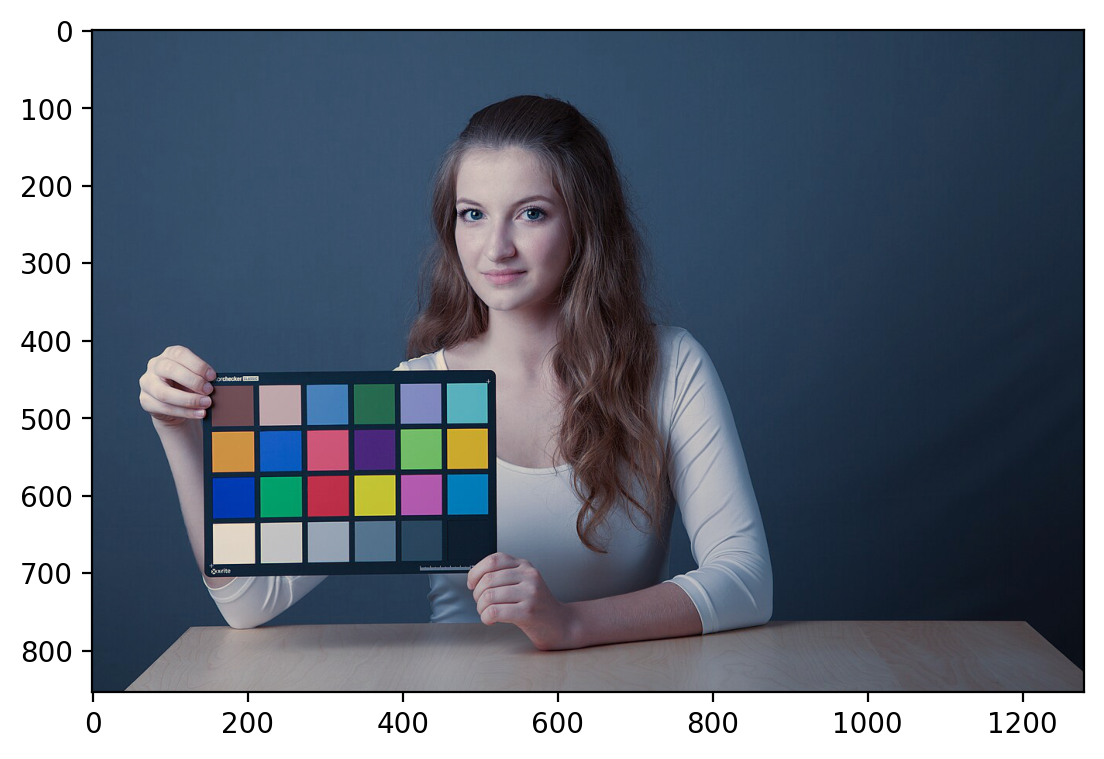

In [9]:

normalized_image = image * (1 / cropped_mean) 
normalized_image *= 0.76
plt.imshow(normalized_image)
plt.show()

In [10]:
assert image.shape == normalized_image.shape, "The normalized image must have the same shape of the original one."

# Problem 2: Triple Birthday Paradox (25 pts)

Let us again consider the [Birthday Paradox](https://en.wikipedia.org/wiki/Birthday_problem) that was introduced during the first week's exercise session. In this task, we will study a slightly modified problem that can be summarized with the following question:

**What is the probability that at least *three* people in a random set of $n$ people share the same birthday? (Take number of days in a year as 365.)**

In the following, you will develop a simple numerical Python program to solve this problem and then make use of vectorization with NumPy arrays to speed it up. For this reason, you should use the "magic" Jupyter function ```%%time``` to profile the execution time of your implementation at every step.

## Problem 2.1: Basic Python Implementation (10 pts)

**TODO**: Write a basic Python program<a name="myfootnote1"><sup>[1]</sup></a> that estimates of the "3-birthdays probability" based on random sampling. 

Feel free to reuse code from the [first weeks notebook](https://moodle.epfl.ch/mod/resource/view.php?id=1260815) to get some inspiration on how you would do this.
The structure should stay exactly the same:
1. Choose $n$ random birthdays (i.e. integers)
2. Check if *three* of the birthdays are the same
3. Repeat this process $K$ times and keep track of how many times it was true
4. Return the ratio between "number successful events" and "total number events" ($K$)

When you chose $K$ large enough, a simulation like this should give you a good estimate of the true probability.

Remember that you can generate random integers by using *```randint```* from the *```random```* module:

```python
import random as rnd
a = rnd.randint(0, 10) # Random integer between 0 and 10 (including)
```
[[1]](#myfootnote1) Do **not** use any of the NumPy, SciPy, ... libraries in this part of the exercise—only pure Python is allowed.

In [11]:
## TODO... Fill in the inner loop of the following function

# For n people, compute an approximation of the probability that at
# least three people share the same birthday, using K iterations
def birthday_paradox_basic(n, K):
    counter = 0 # Keep track of how often the statement is true

    # Perform K iterations of the same experiment.
    for _ in range(K):
        dates = [rnd.randint(0,364) for i in range(n)]
        if len([x for x in dates if dates.count(x) > 2]) > 0:
            counter += 1
        
    # Return average probability
    return counter / K


To test if your program is operating correctly, try running it for $n=88$ people using a very high value of $K$ (e.g. ``100000``). This should give you (in expectation) a probability slightly above $0.5$:

In [12]:
print(birthday_paradox_basic(88, 100000))

0.51307


Finally, profile the running time of the implementation and report how much time it took for $K=100000$. You can do this simply by putting the ["magic command"](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-time) ``%%time`` at the top of the cell that should be timed:

In [13]:
%%time
birthday_paradox_basic(88, 100000)


CPU times: user 5.54 s, sys: 49 ms, total: 5.59 s
Wall time: 5.7 s


0.50928

## Problem 2.2: Vectorized implementation using NumPy (15 pts)

As you likely noticed, an implementation in pure Python is rather slow! As a frame of reference: an implementation with list comprehensions (as was done during the exercise session) can easily take half a minute to complete for large values of $K$ like above. Creating lists of random integers is a particularly slow operation that can be considerably accelerated using vectorized NumPy functions that process entire NumPy arrays at a once.

**TODO**: Write another function that computes the same result, but this time, replace the inner part of the "*```for _ in range(K)```*" loop with a combination of NumPy array functions.<a name="myfootnote2"><sup>[2]</sup></a>

Here are a number of NumPy functions that you may find helpful:
* ```np.random.randint```
* ```np.bincount```
* ```np.unique```
* ```np.min, np.max```
* ```np.arange```
* ```np.any```

You can read about these in the [NumPy Documentation](https://numpy.org/doc/stable/).

**Hint**: The output range of ```np.random.randint``` differs slightly from ```random.randint``` provided by the standard library that you used above. Make sure not to introduce any subtle off-by-one errors!

[[2]](#myfootnote2) In this part of the exercise, do **not** use Python lists and list comprehensions, and do not explicitly iterate over the days of the year. Do **not** use ```np.vectorize```, ```np.apply_along_axis``` (or similar constructs) that merely emulate vectorization using a slow Python ``for`` loop internally.

In [14]:
import numpy as np

def birthday_paradox_numpy(n, K):
    counter = 0
    
    for _ in range(K):
        dates = np.random.randint(0, 365, n)
        unique_dates, counts = np.unique(dates, return_counts=True)
        if np.any(counts > 2):
            counter += 1

    return counter / K

In [15]:
birthday_paradox_numpy(88, 100000)

0.51018

**TODO**: Profile the running time of the implementation vectorized implementation for $K=100000$ like above.

In [16]:
%%time
birthday_paradox_numpy(88, 100000)

CPU times: user 1.01 s, sys: 6.37 ms, total: 1.02 s
Wall time: 1.02 s


0.50753

## Problem 2.3: Optional Exercise (0 points, not graded)
-- --
 <br/>Although the vectorized implementation is a tremendous improvement, it still contains a loop over a potentially large number of virtual experiments. We can do better!

* Implement a version that fully relies on vectorized NumPy functions and contains no more loops. As above, do **not** use ```np.vectorize```, ```np.apply_along_axis``` (or similar constructs) that merely emulate vectorization using a slow Python ``for`` loop internally.
* Again, profile your code and report the speedup compared to both the "pure Python" and previous NumPy implementation. We expect to see at least some additional speedup here. (As a frame of reference, our solution to this problem achieves `~4x` speedup compared to problem 2.2.)




In [17]:
def birthday_paradox_vectorized(n, K):
    result = 0
    birthdays = np.random.randint(0, 365, size=(K, n))
    sorted_birthdays = np.sort(birthdays, axis=1)
    diff = np.diff(sorted_birthdays, axis=1)
    duplicates = (diff == 0)
    same = np.any(duplicates[:, :-1] & duplicates[:, 1:], axis=1)
    result = np.sum(same) / K

    return result

**TODO**: Profile the running time of the implementation vectorized implementation for $K=100000$ like above.

In [18]:
%%time
birthday_paradox_vectorized(88, 100000)

CPU times: user 186 ms, sys: 23.8 ms, total: 210 ms
Wall time: 222 ms


0.51243

### Performance Comparison

We implemented the birthday paradox simulation using three approaches and here is a sample run :  

1. **Problem 2.1: Pure Python**
   - CPU times: user 5.67 s, sys: 73.9 ms, total: 5.74 s  
   - Wall time: 5.95 s  

2. **Problem 2.2: Vectorized implementation using NumPy**
   - CPU times: user 1.06 s, sys: 8.29 ms, total: 1.07 s  
   - Wall time: 1.11 s  

3. **Problem 2.3: Fully vectorized NumPy implementation (no loops)**
   - CPU times: user 189 ms, sys: 35 ms, total: 224 ms  
   - Wall time: 250 ms  

**Observation:**  
- Moving from pure Python (2.1) to NumPy vectorization (2.2) achieves ~5x speedup.  
- Further eliminating loops in the fully vectorized version (2.3) results in a total speedup of ~ 5x compared to NumPy vectorization (2.2) and ~23x compared to the pure Python implementation (2.1). 


## Problem 3: Measuring error using ULPs (25 pts)
-- --

A special property of the IEEE754 floating point specification is that contiguous ranges of floating point numbers are also contiguous when re-interpreted as unsiged integers, e.g. by after applying the function ``f2i`` defined above. See the next figure for an illustration of this.

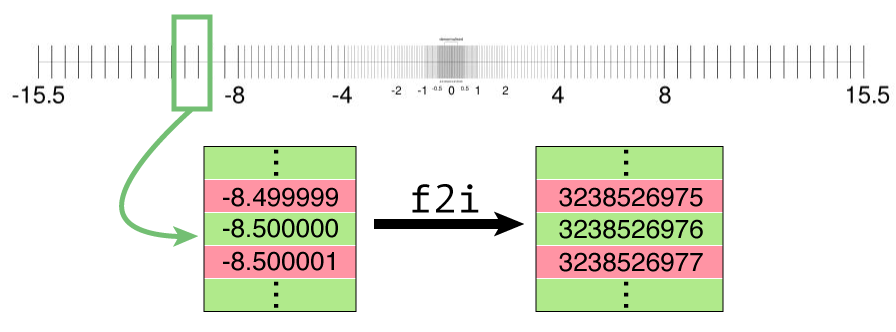

Use this property along with the functions ``f2i`` and ``i2f`` and the aliases ``f16`` etc. defined above to answer the following questions:

1. How many floating point values are located between the values ``1`` and ``2``, including the endpoints? How about ``1001`` and ``1002`` ? Give answers for 16, 32, and 64 bit precision variants. <br><br>

In [19]:
def floating_points_between(val1, val2):
    '''
    Returns the floating points between val1 and val2 for the different resolutions:
    [16, 32, 64]
    '''
    res = []
    for dtype in [f16, f32, f64]:
        v1 = dtype(val1)
        v2 = dtype(val2)
        i1 = f2i(v1)
        i2 = f2i(v2)
        res.append(int(abs(i2 - i1)) + 1)
    return res

In [20]:
assert(len(floating_points_between(1,2)) == 3), 'You should return the solution for each bit precision variant'
print(floating_points_between(1,2))
print(floating_points_between(1001, 1002))


[1025, 8388609, 4503599627370497]
[3, 16385, 8796093022209]


2. How large is 1 ULP for the value $\pi$ expressed in 64 bit arithmetic? Remember that one ULP was defined as the jump that occurred when changing the last mantissa bit from a ``1`` to a ``0`` (or vice versa).<br><br>

In [21]:
def ulp_of_pi():
    '''
    Returns the ULP of pi
    '''
    pi=f64(np.pi)
    pi_int = f2i(pi)
    next_pi = i2f(pi_int + u64(1))
    pi_ulp = f64(next_pi - pi)
    return pi_ulp


pi_ulp = ulp_of_pi()

In [22]:
print("ulp(pi) = %e" % pi_ulp)
assert(type(pi_ulp) == np.float64)


ulp(pi) = 4.440892e-16


3. Suppose that we compute the surface area of the earth from its radius of $\approx 6.371\cdot 10^6m$ using the expression $A=4\pi r^2$. Assuming that the earth is perfectly spherical, and that the discretization of $\pi$ is the only source of error in this computation, bound the absolute error in square meters.

In [23]:
def numeric_error_earth():
    '''
    Returns the error due to the discretization
    '''
    r = 6.371e6   
    pi_err = ulp_of_pi()
    return 4 * pi_err * r**2
    
error_earth = numeric_error_earth()

In [24]:
print(f"absolute error = {error_earth} m^2")

absolute error = 0.07210168639915082 m^2


## Problem 4: Series approximations (27 pts)
-- --

In Lecture 1, we saw how various numerical issues could occur due to the floating point number representation.  
Consider the power series representation of the sine function:

$$
\sin(x)=x-\frac{x^3}{3!}+\frac{x^5}{5!}-\frac{x^7}{7!}+\cdots
$$

**Hint**: the first 20 coefficients of the sine power series representation look like this:

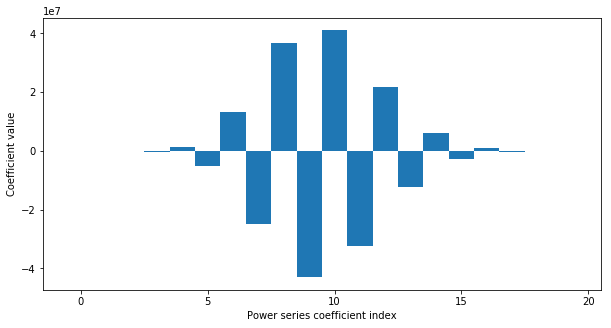

1. Evaluate the power series at \(x=20\) using the first 100 terms and compute the absolute and relative error (you can assume that ``np.sin`` is accurate). *Hint*: the factorial function is provided in ``scipy.special``.<br><br>

In [25]:
import scipy.special as sc
sin_aprox = 0.0
x=20
sign = 1
for i in range(1,201,2):
 sin_aprox+= ( sign * (x**i) ) / sc.factorial(i)
 sign *= -1 
err_abs = abs(sin_aprox - np.sin(x))
err_rel = err_abs / abs(np.sin(x)) 



In [26]:
print(f"Approximated sin: {sin_aprox}")
print(f"err_abs: {err_abs}")
print(f"err_rel: {err_rel}")


Approximated sin: 0.9129452562745278
err_abs: 5.546900161412793e-09
err_rel: 6.075830020466015e-09


2. Express the error as an integer number of ULPs (see also Problem 3) -- in other words, how many floating point numbers are between the true and the approximate answer?<br><br>

In [27]:
diff_int = 0
value=np.sin(20)
value = f64(value) 
value_int = f2i(value)
next_value = i2f(value_int + u64(1))
ulp_value=f64(next_value - value)


diff_int  = err_abs / ulp_value

In [28]:
print(f64(diff_int))

49962035.0


3. Now, evaluate the exponential function at ``x=30`` using the same approach: using its corresponding power series, and assuming that ``np.exp`` is accurate. Specify the absolute and relative error. What do you observe compared to the sine power series?

In [29]:
e_aprox = 0.0
x=30
for i in range(0, 100): 
    e_aprox += x**i / sc.factorial(i)
err_abs = abs(e_aprox - np.exp(x))
err_rel = err_abs / abs(np.exp(x))


In [30]:
print(f"Approximated e: {e_aprox}")
print(f"err_abs: {err_abs}")
print(f"err_rel: {err_rel}")


Approximated e: 10686474581524.467
err_abs: 0.00390625
err_rel: 3.655321472203193e-16


**Observation:**

For large \(x\), the terms \(x^n / n!\) in the exponential series grow very large before decreasing,  
causing significant rounding errors in floating-point arithmetic.  

As a result, the absolute error may still be small in magnitude but corresponds to a huge number of ULPs,  
and the relative error becomes larger.  

In contrast, the sine series remains accurate for moderately large \(x\) because its values are bounded  
between \([-1, 1]\), limiting the accumulation of rounding errors.

#

4. True/False questions (1 pt each, -1 pt if answered incorrectly, please indicate your answers in the code cell below.):

    **(1)** The best way to alleviate the affects of catastrophic cancellation is coupling the terms with similar absolute value but different sign and computing the result of each couple before summing them all.

    **(2)** The computation of sine is more prone to overflow compared to exponential with the same number of terms in the power series.

    **(3)** The aggregate roundoff error is not an issue for exponential computation as all of the values in the power series are positive.

    **(4)** There are more floating point numbers between (1,2) than (-20,-10) range as the representation power of floating points is better in positive numbers.

    **(5)** The power series representation is more accurate for the sine than the exponential computation as the derivative of exponential is strictly increasing.

    **(6)** If the absolute errors of both sine (evaluated at `x=20`) and exponential (evaluated at `x=30`) computations were equal, the sine estimate would have more ULPs between the correct value for the same floating point representation.

    **(7)** The reason of having a higher absolute error in exponential computation as it is more prone to catastrophic cancellation.

    **(8)** For very large inputs, the floating point resolution in the input argument will be coarser than the spacing of individual oscillations. This means that a perturbation by 1 ULP may change the computed result drastically.

**TODO:** Change the variables below to indicate your answers.

In [ ]:
# Change these variables to indicate your answer.
A1 = True
A2 = False
A3 = False
A4 = False
A5 = False
A6 = True
A7 = False
A8 = True


In [32]:
answers = [A1, A2, A3, A4, A5, A6, A7, A8]
for answer in answers:
    assert (answer is None) or (answer is True) or (answer is False), "The answers should be True/False or None!"
print("Congratulations! You finished the first assignment of CS328!")

Congratulations! You finished the first assignment of CS328!
